In [1]:
import imageio
from skimage import morphology
from skimage import segmentation
import numpy as np

from scipy import ndimage as ndi

from skimage.segmentation import watershed
from skimage.feature import peak_local_max


In [2]:
import vigra

In [25]:
img = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/climp/images/climp1_er_mean.png')
skel = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/climp/skel/climp1_proc_skel.png')

In [19]:
# ed = vigra.filters.distanceTransform2D(skel)

In [26]:
# from scipy.ndimage import distance_transform_edt

# scedt = distance_transform_edt(np.invert(skel))

# plt.imshow(scedt)

In [43]:
edt = vigra.filters.distanceTransform2D(skel.astype(np.float32))
vec_edt = vigra.filters.vectorDistanceTransform(skel.astype(np.float32))

edt = np.expand_dims(edt, axis=0)

In [44]:
edt.shape

(1, 128, 128)

In [48]:
vec_edt.shape

v = vec_edt.transpose(2,0,1)
v.shape

(2, 128, 128)

In [38]:
edt_mask = np.concatenate((edt, vec_edt), axis=0)

In [41]:
edt_mask.shape

(3, 128, 128)

In [42]:
from PIL import Image
m = Image.fromarray(edt_mask.transpose(1,2,0))

TypeError: Cannot handle this data type: (1, 1, 3), <f4

In [39]:
edt_mask.shape

(3, 128, 128)

In [23]:
op = op.transpose(2,0,1)

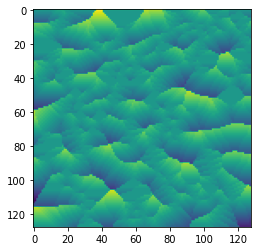

In [24]:
import matplotlib.pyplot as plt

plt.imshow(op[0])

# op.shape

In [85]:
inv = np.logical_not(skel)

invlab = morphology.label(inv, connectivity=1)


bin_invlab = (invlab > 0)
# dilinv = morphology.dilation(inv)

# d1 = morphology.dilation(skel)
# d2 = morphology.dilation(d1)
# l1 = morphology.label(skel)
# ld1 = morphology.label(d1)
# ld2 = morphology.label(d2)

distance = ndi.distance_transform_edt(inv)
labels = morphology.label(distance)

dilabels = morphology.dilation(labels)


invlabel = morphology.label(inv, connectivity=1)

# linv1 = morphology.label(inv)

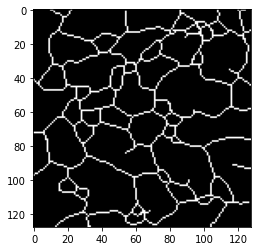

In [96]:
plt.imshow(np.logical_not(bin_invlab), cmap='gray')

In [92]:
newdil = morphology.dilation(skel)
# op = newdil - bin_invlab
vals = np.where(bin_invlab)
newdil[vals] = 0

In [83]:
len(np.where(invlabel==1))

2

(-0.5, 127.5, 127.5, -0.5)

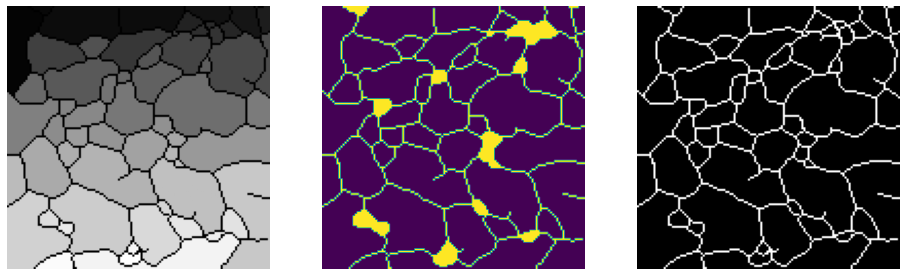

In [94]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16,12))

plt.subplot(131)
plt.imshow(invlab, cmap='gray')
plt.axis('off')

# plt.subplot(142)
# plt.imshow(labels, cmap='gray')
# plt.axis('off')

plt.subplot(132)
plt.imshow(morphology.area_closing(skel))
plt.axis('off')

plt.subplot(133)
# plt.imshow(bin_invlab, cmap='gray')
plt.imshow(newdil, cmap='gray')
plt.axis('off')

(-0.5, 127.5, 127.5, -0.5)

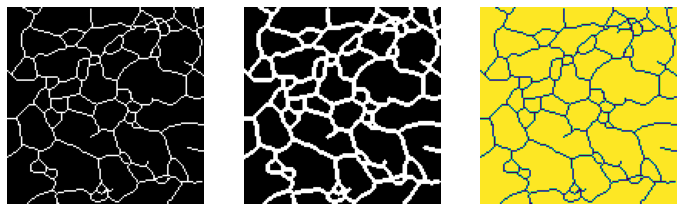

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,12))

plt.subplot(131)
plt.imshow(skel, cmap='gray')
plt.axis('off')

plt.subplot(132)
plt.imshow(d1, cmap='gray')
plt.axis('off')

plt.subplot(133)
plt.imshow(linv1)
plt.axis('off')

In [18]:
slicop = segmentation.slic(img)

/localhome/asa420/anaconda3/envs/as3/lib/python3.7/site-packages/ipykernel_launcher.py:1: FutureWarning: skimage.measure.label's indexing starts from 0. In future version it will start from 1. To disable this warning, explicitely set the `start_label` parameter to 1.
  """Entry point for launching an IPython kernel.


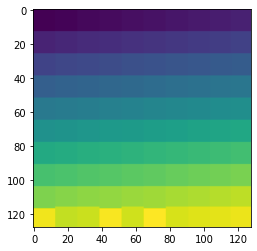

In [19]:
plt.imshow(slicop)

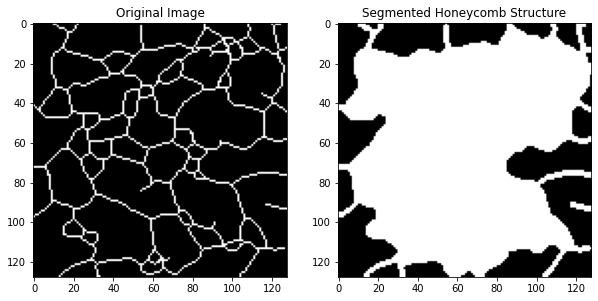

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load your honeycomb image
image = cv2.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/climp/skel/climp1_proc_skel.png', cv2.IMREAD_GRAYSCALE)

# Apply Gaussian blur to smooth the image
blurred = cv2.GaussianBlur(image, (5, 5), 0)

# Apply adaptive thresholding to create a binary image
_, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Find contours in the binary image
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter contours based on area to exclude small noise
# min_contour_area = 1
# filtered_contours = [cnt for cnt in contours if cv2.contourArea(cnt) > min_contour_area]

# Create a mask for visualization
mask = np.zeros_like(image)
# cv2.drawContours(mask, filtered_contours, -1, 255, thickness=cv2.FILLED)
cv2.drawContours(mask, contours, -1, 255, thickness=cv2.FILLED)

# Display the original image and the segmented honeycomb structure
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(mask, cmap='gray')
plt.title('Segmented Honeycomb Structure')

plt.show()


In [97]:
import mclahe as mc

In [99]:
op = mc.mclahe(img)

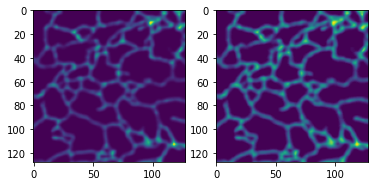

In [101]:
plt.subplot(121)
plt.imshow(img)

plt.subplot(122)
plt.imshow(op)

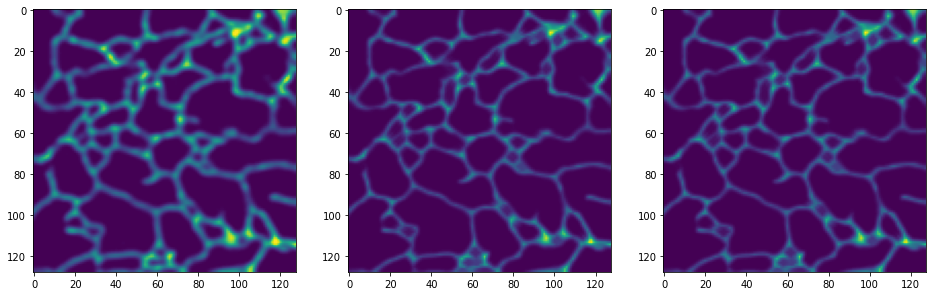

In [123]:
import skimage
from skimage.filters import threshold_local
from skimage import exposure

img = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/climp/images/climp1_er_mean.png')
img = (img - img.min()) / (img.max() - img.min())

# mcop = mc.mclahe(img)
img = exposure.equalize_adapthist(img)
aop = skimage.morphology.area_opening(img, area_threshold=2)
erod = skimage.morphology.erosion(aop)
# aop = skimage.morphology.area_opening(erod, area_threshold=2)
# cl = skimage.morphology.area_closing(aop, area_threshold=32)
# aop = skimage.morphology.area_opening(cl, area_threshold=2)
# aop = skimage.morphology.area_closing(aop)

loc = threshold_local(erod, 3)

plt.figure(figsize=(16, 12))

plt.subplot(131)
plt.imshow(img)

plt.subplot(132)
plt.imshow(threshold_local(erod, 3))

plt.subplot(133)
plt.imshow(loc)

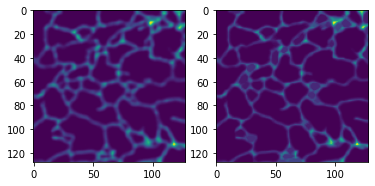

In [107]:
plt.subplot(121)
plt.imshow(img)

plt.subplot(122)
plt.imshow(loc)

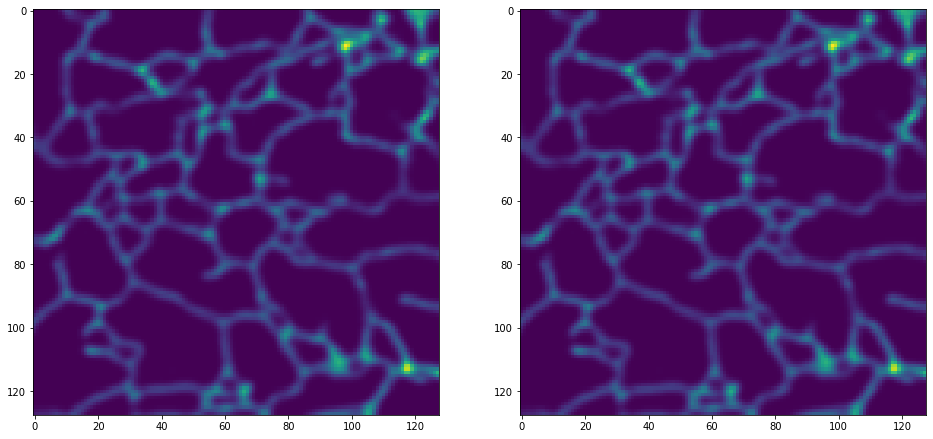

In [113]:
from skimage import exposure

img = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/climp/images/climp1_er_mean.png')
gamma = exposure.equalize_adapthist(img)

k = exposure.rescale_intensity(img)

plt.figure(figsize=(16, 12))

plt.subplot(121)
plt.imshow(img)

plt.subplot(122)
plt.imshow(k)

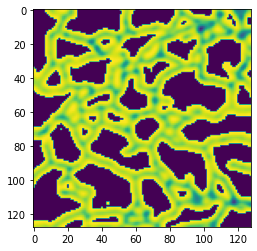

In [124]:
img = imageio.imread('/localhome/asa420/MIAL/data/confocal-data/vess_enh_unet/climp/images/climp1_er_mean.png')

plt.imshow(-img)

In [ ]:
def soft_erode(img):
    if len(img.shape)==4:
        p1 = -F.max_pool2d(-img, (3,1), (1,1), (1,0))
        p2 = -F.max_pool2d(-img, (1,3), (1,1), (0,1))
        return torch.min(p1,p2)
    elif len(img.shape)==5:
        p1 = -F.max_pool3d(-img,(3,1,1),(1,1,1),(1,0,0))
        p2 = -F.max_pool3d(-img,(1,3,1),(1,1,1),(0,1,0))
        p3 = -F.max_pool3d(-img,(1,1,3),(1,1,1),(0,0,1))
        return torch.min(torch.min(p1, p2), p3)